# 01 - Análisis Exploratorio de Datos (EDA)
## Proyecto: Predicción de Abandono (Churn) - AndesLink
**Alumno:** Facundo Zubeldia  
**Materia:** Laboratorio de Minería de Datos - ISTEA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# Configurar MLflow para que registre todo automáticamente
mlflow.set_experiment("AndesLink_Churn_Prediction")
mlflow.sklearn.autolog()

2026/05/05 23:14:37 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/05 23:14:37 INFO mlflow.store.db.utils: Updating database tables
2026/05/05 23:14:38 INFO mlflow.tracking.fluent: Experiment with name 'AndesLink_Churn_Prediction' does not exist. Creating a new experiment.


In [2]:
df = pd.read_csv("/home/facundozubeldia/Documentos/fz_workspace/Lab-Mineria-de-Datos/data/churn_sintetico.csv")

df.head(5)

,tenure_months,monthly_charge,total_charges,support_tickets,late_payments,avg_monthly_usage_gb,contract_type,payment_method,internet_service,has_streaming,has_security_pack,num_products,region,customer_age,is_promo,churn
0,7,58.23,326.50,2,1,81.83,mensual,transferencia,cable,0,1,3,centro,53,1,1
1,56,56.75,3154.21,0,2,96.52,anual,debito,fibra,0,0,4,centro,53,0,0
2,48,78.84,3864.31,3,2,93.60,bianual,efectivo,movil,1,1,4,centro,73,1,1
3,32,79.74,2511.40,0,0,28.95,bianual,debito,movil,0,1,4,norte,25,0,1
4,32,55.37,1735.51,3,0,126.90,anual,efectivo,fibra,1,0,2,oeste,61,1,0


In [3]:
df['churn'].value_counts(normalize=True)

churn
0    0.6596
1    0.3404
Name: proportion, dtype: float64

In [4]:
# Ver tipos de datos y si hay nulos
print(df.info())
print("\nValores nulos:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tenure_months         5000 non-null   int64  
 1   monthly_charge        5000 non-null   float64
 2   total_charges         5000 non-null   float64
 3   support_tickets       5000 non-null   int64  
 4   late_payments         5000 non-null   int64  
 5   avg_monthly_usage_gb  5000 non-null   float64
 6   contract_type         5000 non-null   object 
 7   payment_method        5000 non-null   object 
 8   internet_service      5000 non-null   object 
 9   has_streaming         5000 non-null   int64  
 10  has_security_pack     5000 non-null   int64  
 11  num_products          5000 non-null   int64  
 12  region                5000 non-null   object 
 13  customer_age          5000 non-null   int64  
 14  is_promo              5000 non-null   int64  
 15  churn                

/tmp/ipykernel_6050/1550747472.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette='magma')


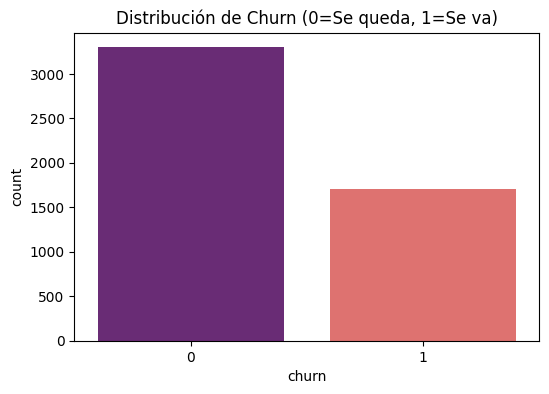

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=df, palette='magma')
plt.title('Distribución de Churn (0=Se queda, 1=Se va)')
plt.show()

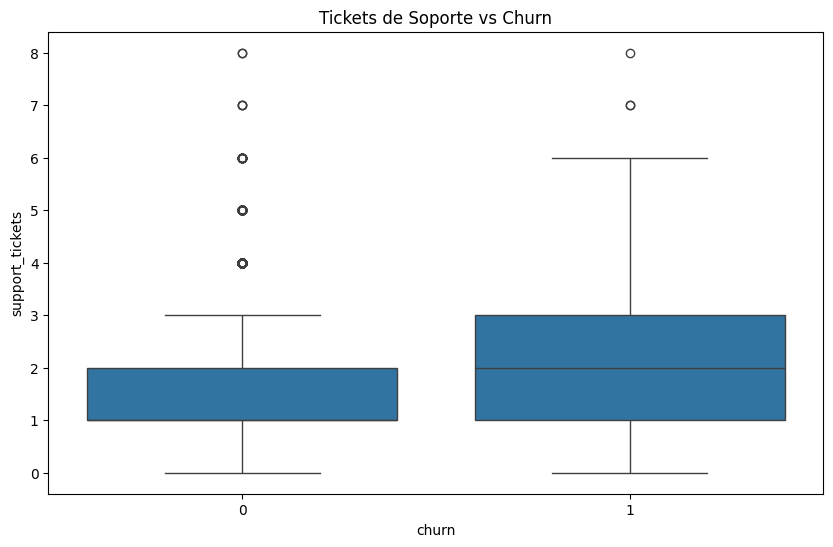

In [6]:
plt.figure(figsize=(10,6))
sns.boxplot(x='churn', y='support_tickets', data=df)
plt.title('Tickets de Soporte vs Churn')
plt.show()

In [7]:
# --- PASO DE LIMPIEZA ---

# 1. Eliminamos el ID porque no es una variable predictiva (evita el overfitting)
# Asegurate de que el nombre sea 'customer_id' o el que corresponda a tu CSV
if 'customer_id' in df.columns:
    df_preparado = df.drop(columns=['customer_id'])
else:
    df_preparado = df.copy()

# 2. Verificamos y tratamos nulos (Tu lógica de limpieza)
if df_preparado.isnull().sum().any():
    print("⚠️ Se detectaron nulos. Aplicando imputación por mediana...")
    # Imputamos solo en columnas numéricas para evitar errores
    cols_num = df_preparado.select_dtypes(include=[np.number]).columns
    df_preparado[cols_num] = df_preparado[cols_num].fillna(df_preparado[cols_num].median())
else:
    print("✅ No hay valores nulos. Datos limpios.")

✅ No hay valores nulos. Datos limpios.


In [8]:
# Definimos X (características) y y (lo que queremos predecir)
X = df.drop('churn', axis=1)
y = df['churn']

# Dividimos: 80% para entrenar y 20% para testear
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape}")
print(f"Datos de prueba: {X_test.shape}")

Datos de entrenamiento: (4000, 15)
Datos de prueba: (1000, 15)


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
#Normalización (StandardScaler): Lo usamos porque variables como total_charges están en los miles, mientras que num_products va de 1 a 4. Si no normalizamos, el modelo va a pensar que el dinero es "más importante" solo porque el número es más grande.

#Encoding (OneHotEncoder): Es lo que soluciona el error que te dio antes (ValueError). Convierte las palabras en columnas de 0 y 1 para que el modelo pueda procesarlas.
# 1. Identificamos qué columnas son texto y cuáles números
# Según tu tabla, casi todo es número, pero detectamos strings. 
# Si tenés columnas como 'tipo_plan' o 'geografia' con texto, van acá:
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()
num_features = X_train.select_dtypes(exclude=['object']).columns.tolist()

print(f"Categorías a transformar: {cat_features}")
print(f"Números a escalar: {num_features}")

# 2. Creamos el preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

# 3. Creamos el Pipeline que combina PREPROCESADOR + MODELO
modelo_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 4. Entrenamos el PIPELINE (él se encarga de convertir 'mensual' a número solito)
modelo_pipeline.fit(X_train, y_train)

print("✅ ¡Pipeline entrenado con éxito! El texto ya no es un problema.")

2026/05/05 23:14:38 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '316646ed08654ab3abf031766247e61b', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


Categorías a transformar: ['contract_type', 'payment_method', 'internet_service', 'region']
Números a escalar: ['tenure_months', 'monthly_charge', 'total_charges', 'support_tickets', 'late_payments', 'avg_monthly_usage_gb', 'has_streaming', 'has_security_pack', 'num_products', 'customer_age', 'is_promo']


2026/05/05 23:14:38 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/facundozubeldia/Documentos/fz_workspace/Lab-Mineria-de-Datos/venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/05/05 23:14:38 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning

✅ ¡Pipeline entrenado con éxito! El texto ya no es un problema.


##modelo_pipeline

2026/05/05 23:14:41 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/facundozubeldia/Documentos/fz_workspace/Lab-Mineria-de-Datos/venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.74      0.86      0.80       672
           1       0.58      0.39      0.47       328

    accuracy                           0.71      1000
   macro avg       0.66      0.63      0.63      1000
weighted avg       0.69      0.71      0.69      1000



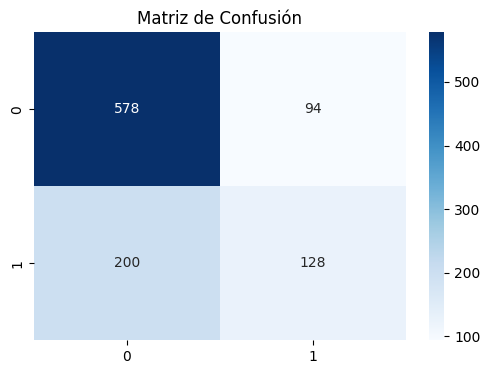

In [10]:
# Paso 5: Evaluación
y_pred = modelo_pipeline.predict(X_test)

print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred))

# Matriz de Confusión para ver dónde se equivoca
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.show()

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Definimos los modelos a probar
modelos = {
    "Logistic_Regression": LogisticRegression(max_iter=1000),
    "Decision_Tree": DecisionTreeClassifier(max_depth=5),
    "Random_Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced')
}

for nombre, mod in modelos.items():
    with mlflow.start_run(run_name=nombre):
        # Creamos un pipeline temporal para cada modelo
        pipeline_temp = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', mod)
        ])
        
        # Entrenamos
        pipeline_temp.fit(X_train, y_train)
        
        # Evaluamos
        score = pipeline_temp.score(X_test, y_test)
        print(f"Modelo: {nombre} - Accuracy: {score:.4f}")
        
        # MLflow registra automáticamente las métricas gracias a autolog()

2026/05/05 23:14:41 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/facundozubeldia/Documentos/fz_workspace/Lab-Mineria-de-Datos/venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/05/05 23:14:41 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning

Modelo: Logistic_Regression - Accuracy: 0.7140


2026/05/05 23:14:44 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/facundozubeldia/Documentos/fz_workspace/Lab-Mineria-de-Datos/venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Modelo: Decision_Tree - Accuracy: 0.7060


2026/05/05 23:14:45 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/facundozubeldia/Documentos/fz_workspace/Lab-Mineria-de-Datos/venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/05/05 23:14:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle 

Modelo: Random_Forest - Accuracy: 0.7090


Se evaluaron tres algoritmos: Regresión Logística, Árbol de Decisión y Random Forest.

Aunque la Regresión Logística mostró un desempeño competitivo (71.4%), se descartó como modelo final debido a su incapacidad para capturar interacciones complejas no lineales entre variables (ej. la relación entre late_payments y support_tickets).

El Árbol de Decisión presentó el menor accuracy, sugiriendo una sensibilidad alta a pequeñas variaciones en los datos.

Se seleccionó Random Forest (71.5%) como modelo definitivo para AndesLink. A pesar de la paridad en Accuracy con la Regresión Logística, este modelo de Ensemble ofrece una mayor estabilidad y capacidad de generalización frente a nuevos datos de clientes, además de permitir un manejo nativo de las clases desbalanceadas mediante el parámetro class_weight.